In [21]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

In [2]:
first_drop = pd.read_csv("first_drop.csv")
later_drops = pd.read_csv("later_drops.csv")
later_drops

,Unnamed: 0,Race,Batch_ID,New_Dem_Prop,New_Total
0,58,CD-21,3,0.459485,2135.0
1,170,CD-45,3,0.563816,13868.0
2,86,CD-22,3,0.495509,13804.0
3,198,CD-47,3,0.535981,9644.0
4,30,CD-13,3,0.487849,14361.0
...,...,...,...,...,...
234,81,CD-21,27,0.590059,2354.0
235,305,SD-19,27,0.388664,247.0
236,53,CD-13,27,0.554726,402.0
237,165,CD-41,27,0.409091,66.0


In [3]:
race_names = later_drops['Race'].unique()
n_races = len(race_names)

race_idx = later_drops['Race'].astype('category').cat.codes.values
race_idx

array([ 2,  6,  3,  7,  1,  4,  0,  8, 10, 12, 11,  9,  5,  6,  9,  7,  4,
        8, 10, 11,  3,  0, 12,  1,  6, 10, 11, 12,  4,  6,  8,  7,  0,  4,
        5,  9,  0, 12,  1, 10,  1, 11,  6,  0,  7,  8,  4, 10,  2,  9,  3,
        3,  2,  5,  4, 12, 11,  2,  3,  8, 10,  5,  4,  6,  7,  9,  0,  1,
        6, 11,  0,  3,  5,  7,  8,  1, 10,  2,  9,  4,  9,  1,  6,  8, 10,
        2,  5, 11,  7, 12,  4,  3,  0,  4,  8,  0,  6, 10, 11,  5,  7,  1,
        2, 10,  9,  1,  0, 11,  7, 12,  6,  2,  4,  5,  8,  3,  9,  7,  0,
       10,  5,  8,  3,  1,  4, 11,  6,  9,  0,  2, 12, 11,  7,  6,  4,  3,
        1,  8,  5, 10,  4,  9,  7,  0,  8,  5, 10,  1,  6, 11,  3,  2,  8,
        7,  4, 11,  6,  1, 12, 10,  3,  0,  2,  9,  5,  0,  1, 11, 10,  8,
        7,  4,  5,  6, 11,  6,  1,  8,  5,  7,  0,  2, 12,  4, 10,  3,  9,
        7,  3, 10,  1,  6,  0, 11,  5,  8,  4,  9,  6, 10,  4,  9, 12,  3,
        1,  2,  5,  7, 11,  0,  8,  1,  9, 12,  3,  9,  0,  8,  4,  7,  6,
       11, 12, 10,  1,  5

In [6]:
b_rt_observed = later_drops['New_Dem_Prop'].values

Start with $\mu_r, \sigma_r^2, \mu_g, \sigma_g^2$ all constant to make sure it works.

In [19]:
with pm.Model() as election_model_v0:
    
    # =========================================================
    # LEFT SIDE: Race-Specific Hierarchical Component (The R Plate)
    # =========================================================
    # NIX_r prior translated into standard independent priors
    mu_r = 0 #pm.Normal('mu_r', mu=0.5, sigma=0.1)       # Baseline Dem lean across all races
    sigma_r = 0.05 #pm.HalfNormal('sigma_r', sigma=0.1)     # How much variance there is between races
    
    # s_r node (Inside the R plate)
    # The latent state for each individual race (shape = n_races)
    s_r = pm.Normal('s_r', mu=mu_r, sigma=sigma_r, shape=n_races)
    
    
    # =========================================================
    # RIGHT SIDE: Global Component (Outside the plates)
    # =========================================================
    # NIX_g prior 
    mu_g = 0 #pm.Normal('mu_g', mu=0.0, sigma=0.05)      # Expected global shift 
    sigma_g = 0.05 #pm.HalfNormal('sigma_g', sigma=0.05)    # Variance of the global shift
    
    # s_g node
    # A single latent global effect affecting all batches/races equally
    s_g = pm.Normal('s_g', mu=mu_g, sigma=sigma_g)


    # =========================================================
    # CENTER: The Observation Layer (The T Plate nested in R)
    # =========================================================
    # The expected value for each specific batch update is the sum of its 
    # race-specific effect and the global effect.
    # We use race_idx to broadcast the right s_r to the right row.
    expected_b = s_r[race_idx] + s_g + first_drop["Dem_Prop_Before_11_08"].values[race_idx]
    
    # Observation noise (Implicit in continuous generative models)
    sigma_batch = 0.05
    
    # b_{r,t} node (Shaded = observed data)
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch, 
                     observed=b_rt_observed)

In [28]:
with election_model_v0:
    # This runs Markov Chain Monte Carlo (MCMC) to find the most likely 
    # values for all your latent variables (s_r, s_g, etc.) based on your data.
    trace_v0 = pm.sample(draws=2000, tune=1000, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [s_r, s_g]


/Users/jackhlavka/Files/Class Work/Stats 305C/election_project/.venv/lib/python3.11/site-packages/rich/live.py:260:
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


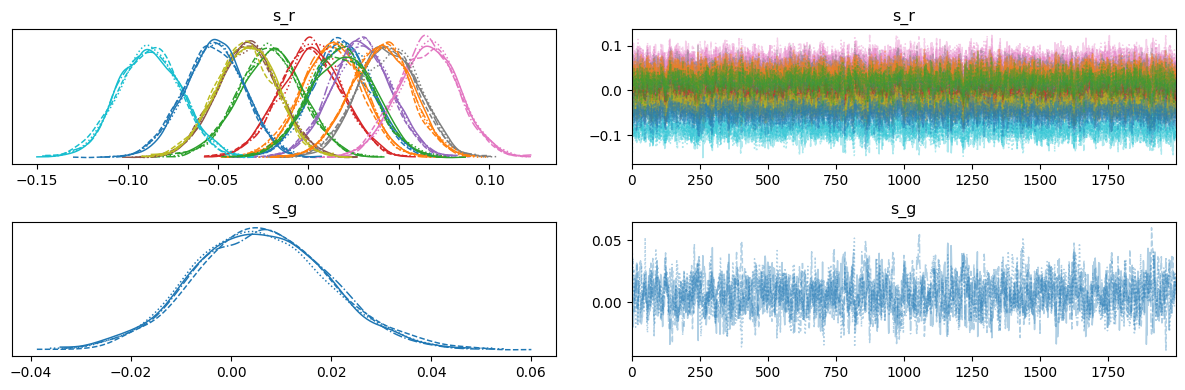

In [29]:
# This generates the classic two-column plot: 
# Left side = the posterior distributions
# Right side = the "caterpillar" plots showing the path of the 4 chains
az.plot_trace(trace_v0)
plt.tight_layout()
plt.show()

In [ ]:
with pm.Model() as election_model_v1:
    
    # 1. Hyperparameters
    # mu_r is completely GONE. 
    sigma_r = pm.HalfNormal('sigma_r', sigma=0.1)     
    
    # The global shift now handles the entire baseline mean
    mu_g = pm.Normal('mu_g', mu=0.0, sigma=0.05)      
    sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
    
    sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.05)

    # 2. Race-Specific Latent State (Non-centered, mean fixed to 0)
    z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
    
    # s_r is now just the race's specific deviation from the global trend
    s_r = pm.Deterministic('s_r', z_r * sigma_r) 
    
    # 3. Global Latent State (Non-centered)
    z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
    s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

    # 4. Observation Layer 
    baseline = first_drop["Dem_Prop_Before_11_08"].values[race_idx]
    
    expected_b = s_r[race_idx] + s_g + baseline
    
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch, 
                     observed=b_rt_observed)

In [32]:
with election_model_v1:
    # This runs Markov Chain Monte Carlo (MCMC) to find the most likely 
    # values for all your latent variables (s_r, s_g, etc.) based on your data.
    trace_v1 = pm.sample(draws=2000, tune=1000, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, mu_g, sigma_g, sigma_batch, z_r, z_g]


/Users/jackhlavka/Files/Class Work/Stats 305C/election_project/.venv/lib/python3.11/site-packages/rich/live.py:260:
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


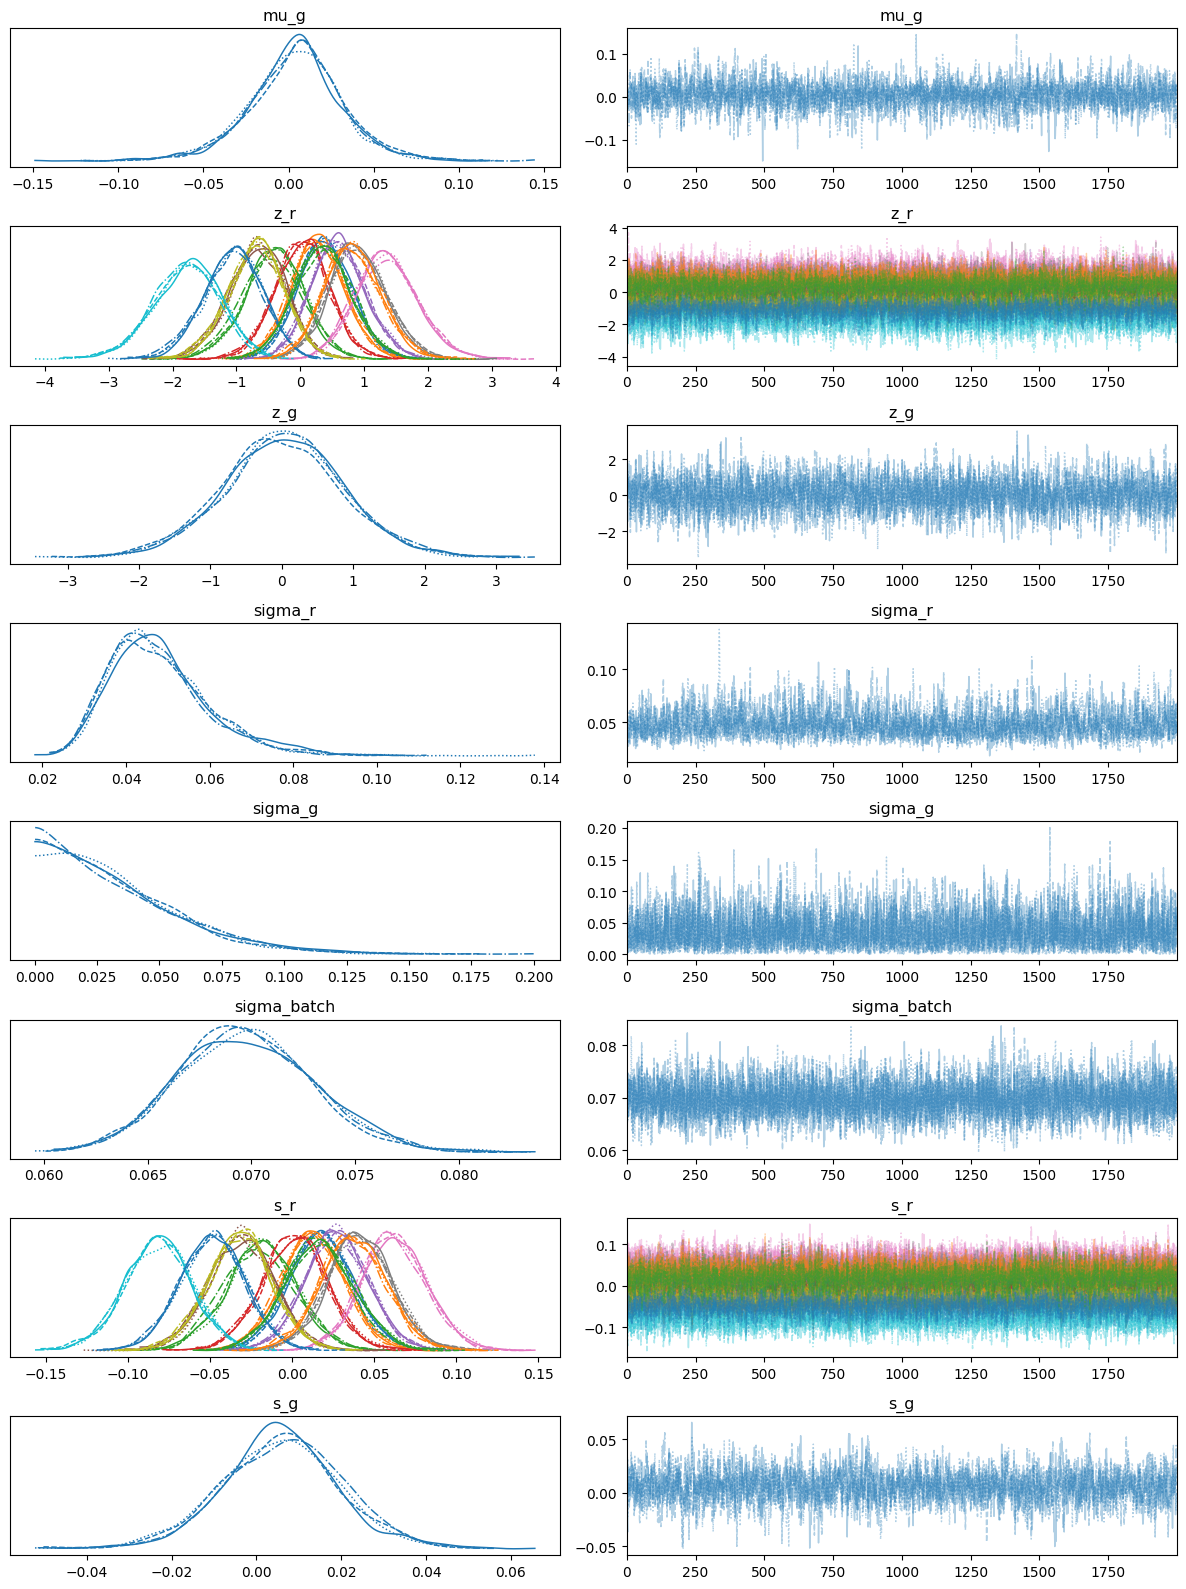

In [33]:
az.plot_trace(trace_v1)
plt.tight_layout()
plt.show()